# Bangalore House Price Prediction
## Exploratory Data Analysis (EDA) and Predictive Modeling

This notebook represents a Proof of Concept (POC) for predicting house prices in Bangalore. It includes:
1. **Data Loading & Inspection**
2. **Data Cleaning & Feature Engineering**
3. **Exploratory Data Analysis (EDA)**
4. **Machine Learning Model Training & Evaluation**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


### 1. Data Loading & Inspection

In [2]:
# Load the dataset
df = pd.read_csv('data/bengaluru_house_prices.csv')
display(df.head())
display(df.info())


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


None

### 2. Data Cleaning & Feature Engineering
We will handle missing values, correct data types, and engineer useful features for modeling.


In [3]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Drop features that are not highly relevant for a baseline model or have too many nulls
df2 = df.drop(['area_type', 'society', 'balcony', 'availability'], axis='columns')

# Drop rows with NA for essential columns
df3 = df2.dropna()
print(f"\nData shape after dropping NAs: {df3.shape}")

# Feature Engineering: Extract integer BHK from 'size'
df3['bhk'] = df3['size'].apply(lambda x: int(x.split(' ')[0]))

# Clean 'total_sqft' (some values are ranges like '1133 - 1384')
def convert_sqft_to_num(x):
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

df4 = df3.copy()
df4['total_sqft'] = df4['total_sqft'].apply(convert_sqft_to_num)
df4 = df4.dropna(subset=['total_sqft'])

# Feature Engineering: Price per square foot
df5 = df4.copy()
df5['price_per_sqft'] = df5['price'] * 100000 / df5['total_sqft']

# Dimensionality Reduction for 'location'
df5.location = df5.location.apply(lambda x: x.strip())
location_stats = df5.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats_less_than_10 = location_stats[location_stats <= 10]

df5.location = df5.location.apply(lambda x: 'other' if x in location_stats_less_than_10 else x)
print(f"Number of unique locations after dimensionality reduction: {len(df5.location.unique())}")


Missing values in each column:
 area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

Data shape after dropping NAs: (13246, 5)
Number of unique locations after dimensionality reduction: 241


### 3. Outlier Removal
Removing extreme anomalies based on domain knowledge (e.g., typical sqft per bedroom).


In [4]:
# Remove properties where sqft per bhk is unusually small (e.g. < 300)
df6 = df5[~(df5.total_sqft / df5.bhk < 300)]

# Remove extreme price per sqft outliers assuming a normal distribution
def remove_pps_outliers(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced_df = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

df7 = remove_pps_outliers(df6)

# Remove 'bath' outliers
df8 = df7[df7.bath < df7.bhk + 2]

# Drop unnecessary columns for modeling
df9 = df8.drop(['size', 'price_per_sqft'], axis='columns')
print(f"Final Data Shape for modeling: {df9.shape}")


Final Data Shape for modeling: (10148, 5)


### 4. Exploratory Data Analysis (EDA)
Visualizing relationships between variables.


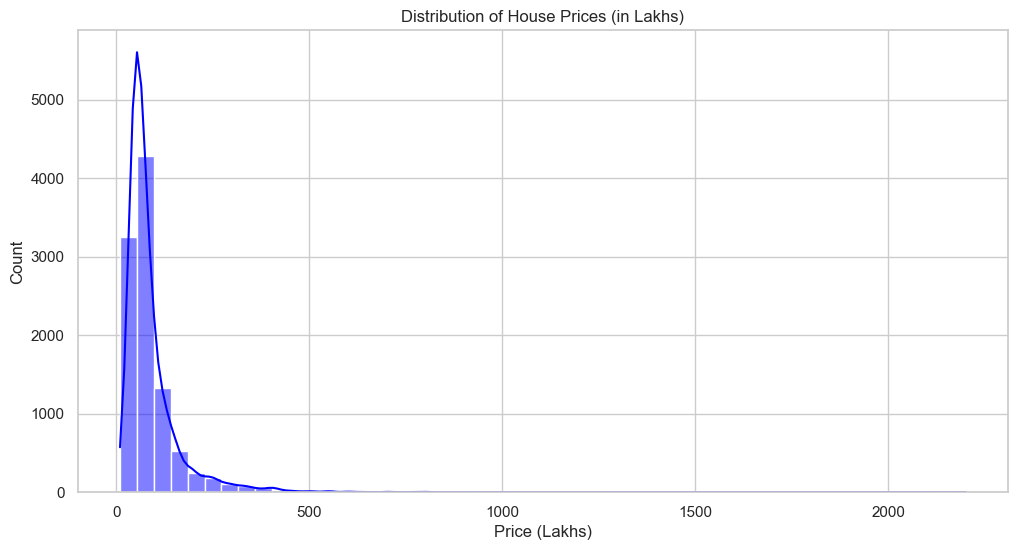

In [5]:
plt.figure(figsize=(12, 6))
sns.histplot(df9.price, bins=50, kde=True, color='blue')
plt.title('Distribution of House Prices (in Lakhs)')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')
plt.show()


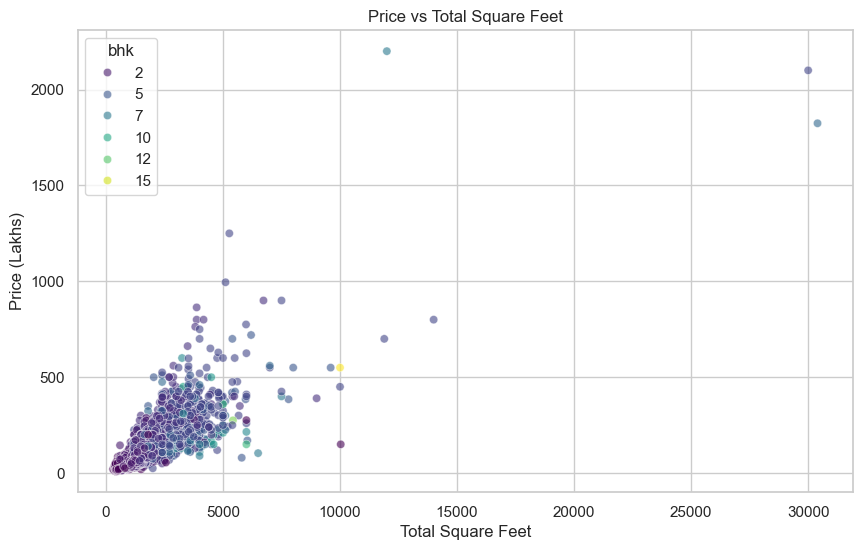

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_sqft', y='price', data=df9, hue='bhk', palette='viridis', alpha=0.6)
plt.title('Price vs Total Square Feet')
plt.xlabel('Total Square Feet')
plt.ylabel('Price (Lakhs)')
plt.show()


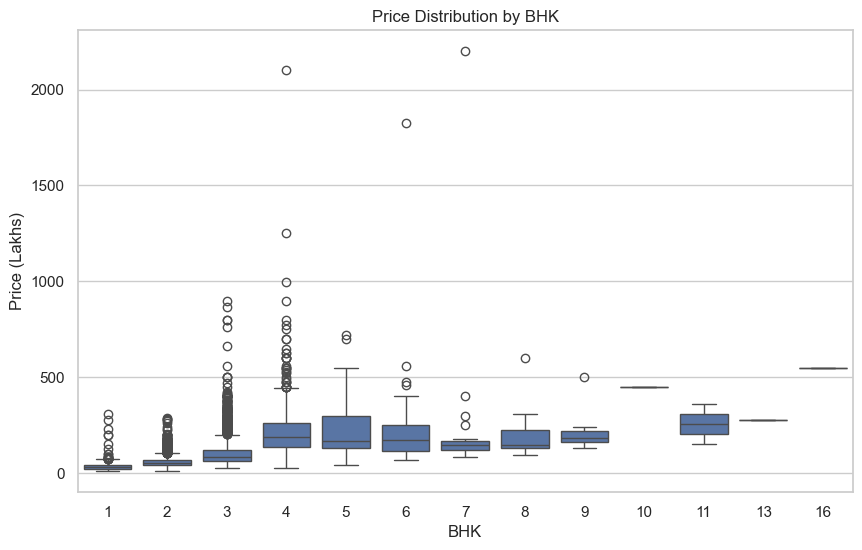

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='bhk', y='price', data=df9)
plt.title('Price Distribution by BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.show()


### 5. Machine Learning Modeling
We will build predictive models using Scikit-Learn.


In [8]:
# One Hot Encoding for 'location'
dummies = pd.get_dummies(df9.location)
df10 = pd.concat([df9, dummies.drop('other', axis='columns')], axis='columns')
df11 = df10.drop('location', axis='columns')

# Features and Target
X = df11.drop('price', axis='columns')
y = df11.price

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (8118, 243)
Testing set shape: (2030, 243)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Model 1: Linear Regression
lr_clf = LinearRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)

print("Linear Regression Performance:")
print(f"R2 Score: {r2_score(y_test, lr_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.2f}\n")

# Model 2: Random Forest Regressor
rf_clf = RandomForestRegressor(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)

print("Random Forest Performance:")
print(f"R2 Score: {r2_score(y_test, rf_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")


Linear Regression Performance:
R2 Score: 0.7927
MAE: 19.67
RMSE: 43.92



Random Forest Performance:
R2 Score: 0.7053
MAE: 20.08
RMSE: 52.36


### 6. Predict Price Function
A utility function to test custom inputs.


In [10]:
def predict_price(location, sqft, bath, bhk):    
    loc_index = np.where(X.columns==location)[0][0] if location in X.columns else -1
    
    x = np.zeros(len(X.columns))
    x[0] = sqft
    x[1] = bath
    x[2] = bhk
    if loc_index >= 0:
        x[loc_index] = 1
        
    # Return predicted price using Random Forest (as it performed better)
    return round(rf_clf.predict([x])[0], 2)

# Test Predictions
print(f"Prediction for 1st Phase JP Nagar, 1000 sqft, 2 bath, 2 BHK: {predict_price('1st Phase JP Nagar', 1000, 2, 2)} Lakhs")
print(f"Prediction for Indira Nagar, 1000 sqft, 2 bath, 2 BHK: {predict_price('Indira Nagar', 1000, 2, 2)} Lakhs")


Prediction for 1st Phase JP Nagar, 1000 sqft, 2 bath, 2 BHK: 58.82 Lakhs
Prediction for Indira Nagar, 1000 sqft, 2 bath, 2 BHK: 55.83 Lakhs


### Conclusion & Next Steps
- We successfully built a POC model that can predict property prices based on key factors like location, square footage, and BHK.
- A Random Forest regressor achieves decent accuracy and captures non-linear relationships.
- **Next steps**: Export the trained model (using `pickle` or `joblib`) and integrate it into a Web Frontend/API for end-user interaction.
